In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/telescope_data.csv')
df

,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
...,...,...,...,...,...,...,...,...,...,...,...,...
19015,19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19016,19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19017,19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19018,19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


In [3]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [4]:
df.isnull().sum()

,0
fLength,0
fWidth,0
fSize,0
fConc,0
fConc1,0
fAsym,0
fM3Long,0
fM3Trans,0
fAlpha,0
fDist,0


In [5]:
X=df.drop('class',axis=1)
y=df['class']

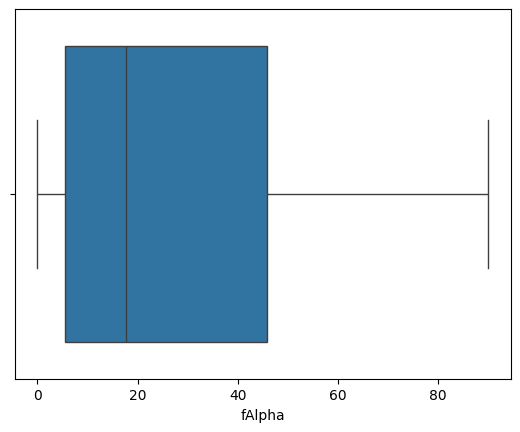

In [6]:
sns.boxplot(x=df['fAlpha'])
plt.show()

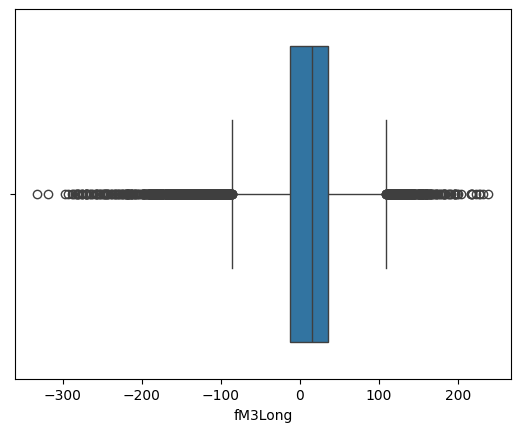

In [7]:
sns.boxplot(x=df['fM3Long'])
plt.show()

(array([  15.,   52.,  167.,  432.,  875., 6512., 9080., 1684.,  177.,
          26.]),
 array([-331.78  , -274.7699, -217.7598, -160.7497, -103.7396,  -46.7295,
          10.2806,   67.2907,  124.3008,  181.3109,  238.321 ]),
 <BarContainer object of 10 artists>)

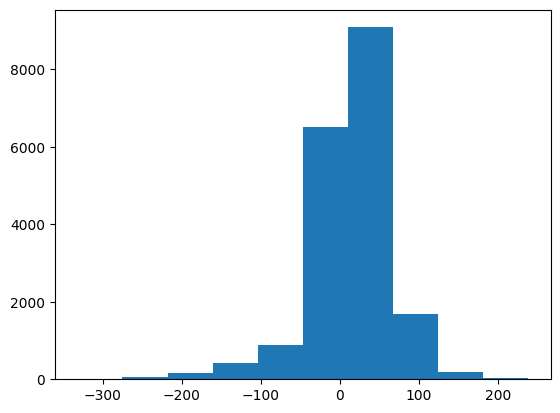

In [8]:
plt.hist(df["fM3Long"])

In [9]:
indexes = df[df["fM3Long"]<-100].index

In [10]:
df.drop(indexes, axis = 0, inplace = True)

In [11]:
indexes = df[df["fM3Long"]>100].index

In [12]:
df.drop(indexes, axis = 0, inplace = True)

(array([ 246.,  293.,  486., 1481., 3384., 4606., 3553., 1834., 1323.,
         663.]),
 array([-9.998440e+01, -7.999695e+01, -6.000950e+01, -4.002205e+01,
        -2.003460e+01, -4.715000e-02,  1.994030e+01,  3.992775e+01,
         5.991520e+01,  7.990265e+01,  9.989010e+01]),
 <BarContainer object of 10 artists>)

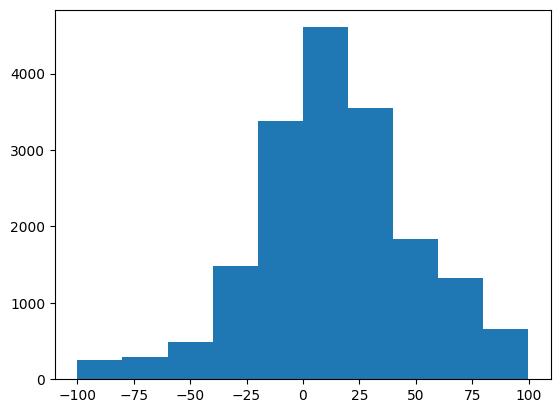

In [13]:
plt.hist(df["fM3Long"])

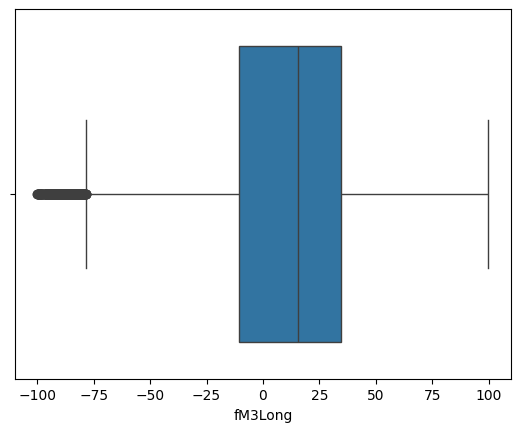

In [14]:
sns.boxplot(x=df['fM3Long'])
plt.show()

In [18]:
indexes = df[df["fM3Long"]<-76].index

In [19]:
df.drop(indexes, axis = 0, inplace = True)

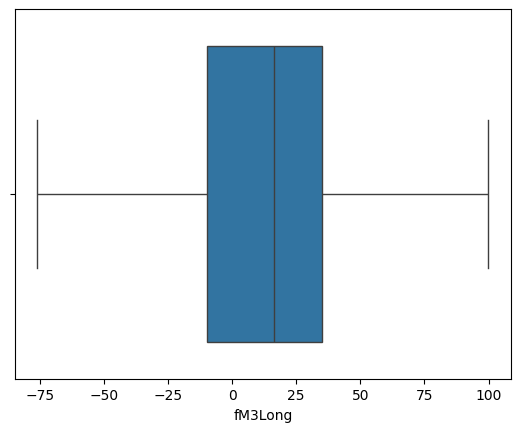

In [20]:
sns.boxplot(x=df['fM3Long'])
plt.show()

(array([ 264.,  427., 1060., 3453., 2317., 4873., 2092., 1456., 1079.,
         543.]),
 array([-75.8655 , -58.28994, -40.71438, -23.13882,  -5.56326,  12.0123 ,
         29.58786,  47.16342,  64.73898,  82.31454,  99.8901 ]),
 <BarContainer object of 10 artists>)

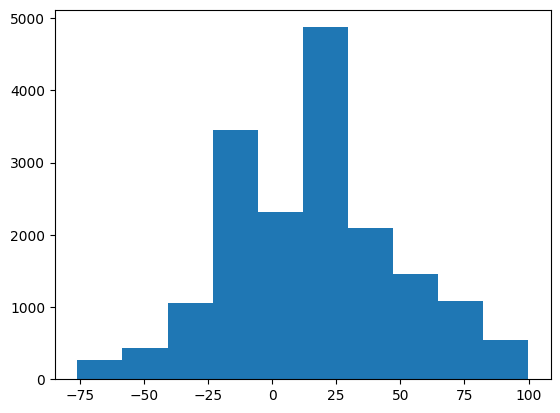

In [21]:
plt.hist(df["fM3Long"])

In [22]:
df["fM3Long"].fillna(df["fM3Long"].mean(),inplace=True)

/tmp/ipykernel_7993/3945196052.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["fM3Long"].fillna(df["fM3Long"].mean(),inplace=True)


In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train, x_test, y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
lr = LogisticRegression()

In [30]:
lr.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [35]:
y_pred = lr.predict(x_test)

In [36]:
from sklearn.metrics import classification_report

In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           g       0.80      0.90      0.85      2444
           h       0.77      0.60      0.67      1360

    accuracy                           0.79      3804
   macro avg       0.78      0.75      0.76      3804
weighted avg       0.79      0.79      0.78      3804



In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [44]:
X = df.drop('class', axis=1)
y = df['class']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
from sklearn.model_selection import GridSearchCV


In [48]:
pg = {"penalty" : ["l1","l2","elasticnet"],
     "C":[0.5,1,3,5],
     "solver" : ["lbfgs", "liblinear"]}

In [55]:
grid_search_lr = GridSearchCV(LogisticRegression(),param_grid = pg, cv = 5, n_jobs = 8)

In [57]:
grid_search_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=8,
             param_grid={'C': [0.5, 1, 3, 5],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear']})

In [58]:
df = pd.DataFrame(data = grid_search_lr.cv_results_)

In [59]:
grid_search_lr.best_score_

np.float64(0.7795885761453162)

In [60]:
grid_search_lr.best_params_

{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

In [61]:
lr = LogisticRegression(C=0.5, penalty="l2", solver="lbfgs")

In [63]:
lr.fit(X_train,y_train)

LogisticRegression(C=0.5)

In [66]:
y_pred = lr.predict(X_test)

In [67]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           g       0.81      0.90      0.85      2460
           h       0.68      0.50      0.58      1053

    accuracy                           0.78      3513
   macro avg       0.74      0.70      0.71      3513
weighted avg       0.77      0.78      0.77      3513



In [70]:
from sklearn.svm import SVC

In [74]:
grid_search_svm = GridSearchCV(SVC(),param_grid = svm_grid, cv = 5, n_jobs = 8)

In [75]:
grid_search_svm.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=8,
             param_grid={'C': [0.5, 1, 3], 'degree': [2, 3, 4],
                         'kernel': ['poly', 'rbf', 'sigmoid']})

In [76]:
grid_search_svm.best_score_

np.float64(0.867056290045082)

In [77]:
grid_search_svm.best_params_

{'C': 3, 'degree': 2, 'kernel': 'rbf'}

In [78]:
svm = SVC(C=3, kernel="rbf")

In [79]:
svm.fit(X_train,y_train)

SVC(C=3)

In [80]:
y_pred = svm.predict(X_test)

In [81]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           g       0.87      0.95      0.91      2460
           h       0.86      0.67      0.76      1053

    accuracy                           0.87      3513
   macro avg       0.87      0.81      0.83      3513
weighted avg       0.87      0.87      0.86      3513

